#📌 Extracão

In [1]:
import pandas as pd
import requests

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json'

In [6]:
response = requests.get(url)
dados_json = response.json()

In [7]:
df = pd.json_normalize(dados_json)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformação

In [9]:
url_dict = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_dicionario.md'
response_dict = requests.get(url_dict)
response_dict.raise_for_status()
dict_md = response_dict.text
print(dict_md[:500])

#### Dicionário de dados

* `customerID`: número de identificação único de cada cliente
* `Churn`: se o cliente deixou ou não a empresa 
* `gender`: gênero (masculino e feminino) 
* `SeniorCitizen`: informação sobre um cliente ter ou não idade igual ou maior que 65 anos 
* `Partner`:  se o cliente possui ou não um parceiro ou parceira
* `Dependents`: se o cliente possui ou não dependentes
* `tenure`:  meses de contrato do cliente
* `PhoneService`: assinatura de serviço telefônico 
* `MultipleLin


In [10]:
print(df.dtypes)
print(df.iloc[0])

customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object
customerID                     0002-ORFBO
Churn                                  No
customer.gender                    Female
customer.SeniorCitizen                  0
customer.Partner                      Yes

In [11]:
df = pd.json_normalize(dados_json, sep = '.')
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [13]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [14]:
print('Strings vazia:')
print((df == '').sum())

Strings vazia:
customerID                     0
Churn                        224
customer.gender                0
customer.SeniorCitizen         0
customer.Partner               0
customer.Dependents            0
customer.tenure                0
phone.PhoneService             0
phone.MultipleLines            0
internet.InternetService       0
internet.OnlineSecurity        0
internet.OnlineBackup          0
internet.DeviceProtection      0
internet.TechSupport           0
internet.StreamingTV           0
internet.StreamingMovies       0
account.Contract               0
account.PaperlessBilling       0
account.PaymentMethod          0
account.Charges.Monthly        0
account.Charges.Total          0
dtype: int64


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [19]:
# Removendo vazios
df = df[df['Churn'].notnull()]
df = df[df['Churn'] != '']

# Removendo linhas duplicadas
df = df.drop_duplicates()

colunas_categoricas = [
    'Churn',
    'customer.gender',
    'customer.Partner',
    'customer.Dependents',
    'phone.PhoneService',
    'phone.MultipleLines',
    'internet.InternetService',
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies',
    'account.Contract',
    'account.PaperlessBilling',
    'account.PaymentMethod'
]

for col in colunas_categoricas:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Convertendo colunas categóricas
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Preenchendo nans
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# Garantindo que ternure e SeniorCitizen sejam inteiros
df['customer.tenure'] = df['customer.tenure'].astype(int)
df['customer.SeniorCitizen'] = df['customer.SeniorCitizen'].astype(int)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,Dsl,...,Yes,No,Yes,Yes,No,One Year,Yes,Mailed Check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,Dsl,...,No,No,No,No,Yes,Month-To-Month,No,Mailed Check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber Optic,...,No,Yes,No,No,No,Month-To-Month,Yes,Electronic Check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber Optic,...,Yes,Yes,No,Yes,Yes,Month-To-Month,Yes,Electronic Check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber Optic,...,No,No,Yes,Yes,No,Month-To-Month,Yes,Mailed Check,83.9,267.40


In [20]:
# Criar a coluna Contas_Diarias a partir do valor mensal
df['Contas_Diarias'] = df['account.Charges.Monthly'] / 30

df[['account.Charges.Monthly', 'Contas_Diarias']].head()

,account.Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


#📊 Carga e análise

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer.SeniorCitizen,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000,1.000000
customer.tenure,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000
account.Charges.Monthly,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000
account.Charges.Total,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000
Contas_Diarias,7043.0,2.158723,1.003002,0.608333,1.183333,2.345,2.995,3.958333


In [22]:
# Medianas
df.median(numeric_only = True)

,0
customer.SeniorCitizen,0.000
customer.tenure,29.000
account.Charges.Monthly,70.350
account.Charges.Total,1394.550
Contas_Diarias,2.345


In [23]:
# CLientes por status de evasão
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [25]:
# Média de gasto mensal por cada tipo de contrato
df.groupby('account.Contract')['account.Charges.Monthly'].mean()

,account.Charges.Monthly
account.Contract,
Month-To-Month,66.398490
One Year,65.048608
Two Year,60.770413


In [26]:
# Desvio padrão do valor diário
df['Contas_Diarias'].std()

1.0030015699226154

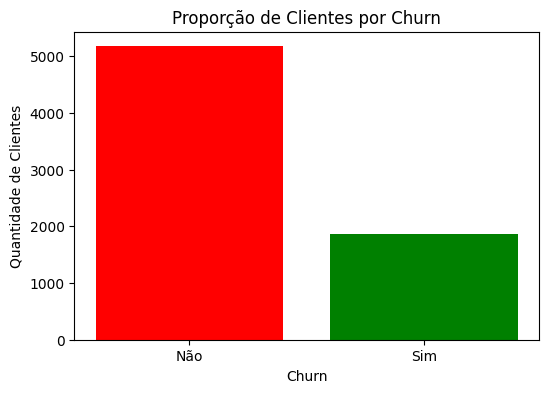

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['Churn'].value_counts()

# Map colors to churn status
color_map = {'Não': 'red', 'Sim': 'green'}
colors = [color_map[churn_status] for churn_status in counts.index]

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)
plt.title('Proporção de Clientes por Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade de Clientes')
plt.show()

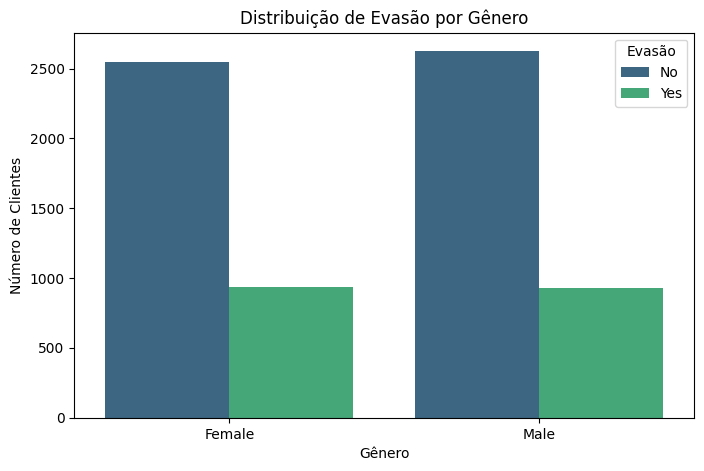

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer.gender', hue='Churn', data=df, palette='viridis')
plt.title('Distribuição de Evasão por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Clientes')
plt.legend(title='Evasão')
plt.show()

In [37]:
# Mapear 'Female' para 'Feminino' e 'Male' para 'Masculino'
df['customer.gender'] = df['customer.gender'].replace({'Female': 'Feminino', 'Male': 'Masculino'})

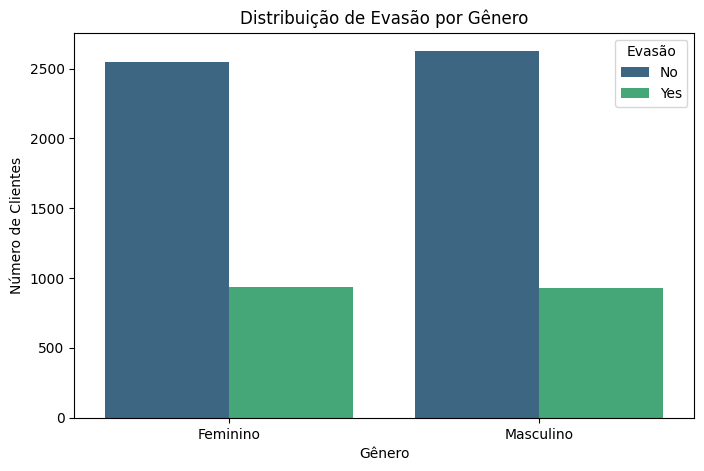

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='customer.gender', hue='Churn', data=df, palette='viridis')
plt.title('Distribuição de Evasão por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Clientes')
plt.legend(title='Evasão')
plt.show()

In [41]:
# Substituir 'Yes' por 'Sim' e 'No' por 'Não' na coluna 'Churn'
df['Churn'] = df['Churn'].replace({'Yes': 'Sim', 'No': 'Não'})

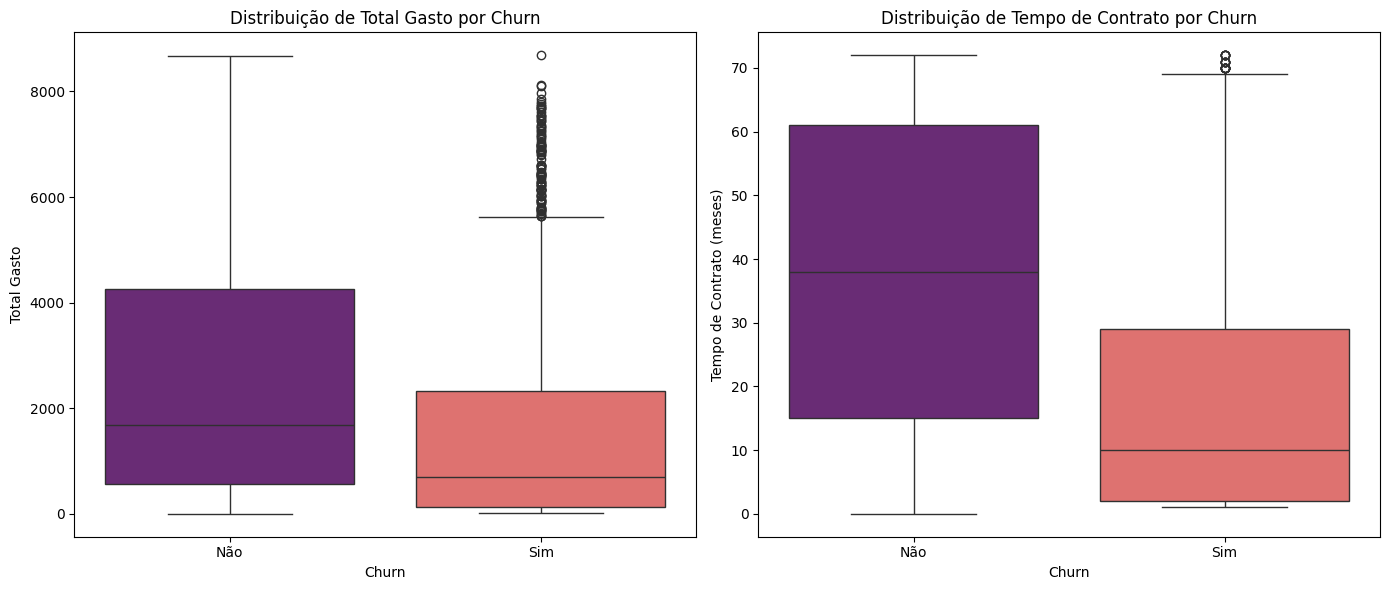

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(x='Churn', y='account.Charges.Total', hue='Churn', data=df, palette='magma', ax=axes[0], legend=False)
axes[0].set_title('Distribuição de Total Gasto por Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Total Gasto')

sns.boxplot(x='Churn', y='customer.tenure', hue='Churn', data=df, palette='magma', ax=axes[1], legend=False)
axes[1].set_title('Distribuição de Tempo de Contrato por Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tempo de Contrato (meses)')

plt.tight_layout()
plt.show()

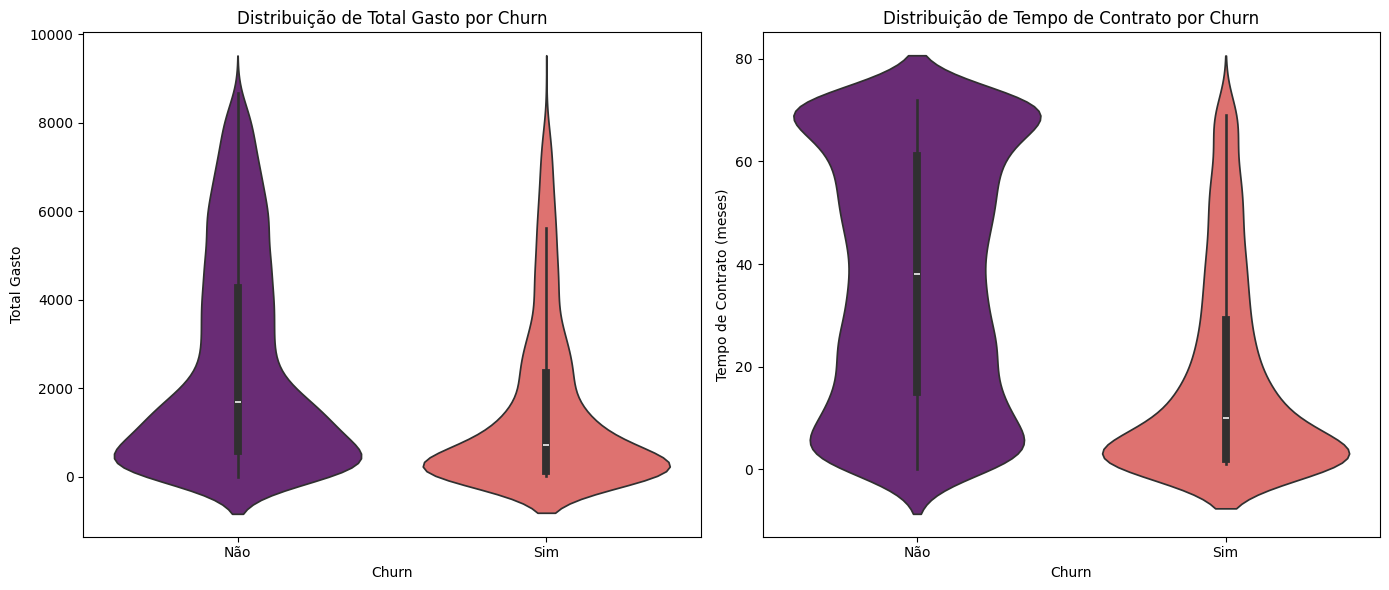

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.violinplot(x='Churn', y='account.Charges.Total', hue='Churn', data=df, palette='magma', ax=axes[0], legend=False)
axes[0].set_title('Distribuição de Total Gasto por Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Total Gasto')

sns.violinplot(x='Churn', y='customer.tenure', hue='Churn', data=df, palette='magma', ax=axes[1], legend=False)
axes[1].set_title('Distribuição de Tempo de Contrato por Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Tempo de Contrato (meses)')

plt.tight_layout()
plt.show()

#📄Relatorio Final

1. Panorama Estratégico
A perda de clientes, tecnicamente denominada Churn, representa um dos maiores obstáculos para a sustentabilidade de modelos de negócio baseados em recorrência. Este relatório detalha a análise exploratória conduzida para decifrar os gatilhos que levam ao cancelamento, permitindo a elaboração de táticas preventivas e o fortalecimento do LTV (Lifetime Value).

2. Higienização e Estruturação da Base
Para garantir a integridade das conclusões, os dados brutos passaram por um rigoroso processo de refinamento:

Mapeamento de Variáveis: Inspeção detalhada de colunas demográficas, financeiras e de consumo.

Padronização Nominal: Ajuste de nomenclaturas complexas (ex: de account.Charges.Total para termos mais acessíveis) para agilizar o processamento.

Saneamento de Dados: Tratamento de inconsistências e valores ausentes para evitar distorções estatísticas.

Segmentação Tipológica: Separação entre dados quantitativos (numéricos) e qualitativos (categóricos).

3. Diagnóstico dos Indicadores (EDA)
3.1 Radiografia do Churn
Iniciamos com a volumetria da base, contrastando o percentual de clientes ativos versus o volume de evasão para estabelecer o baseline da operação.

3.2 Comportamento por Perfil e Contrato
Através de cruzamentos categóricos, investigamos a influência de:

Modalidades Contratuais: Identificação de quais formatos de adesão são mais voláteis.

Fluxo de Pagamento: Avaliação de como o método de cobrança impacta a permanência.

Demografia: Verificação de tendências específicas por gênero ou perfil socioeconômico.

3.3 Métricas Financeiras e Temporalidade
Utilizando visualizações de densidade e dispersão (Boxplots), observamos o impacto de:

Tenure (Tempo de Casa): A correlação entre o tempo de relacionamento e a fidelidade.

Ticket Médio e Gasto Acumulado: O comportamento de churn em diferentes faixas de investimento do cliente.

4. Principais Descobertas e Insights
📉 Vulnerabilidade Inicial: Clientes em estágios iniciais de contrato apresentam a maior taxa de atrito.

💰 Baixo Engajamento Financeiro: Existe uma concentração de cancelamentos em perfis com menor faturamento acumulado.

⚖️ Neutralidade de Gênero: O sexo do cliente não se mostrou um fator determinante ou preditivo para a evasão.

💳 Sensibilidade Contratual: Certos modelos de pagamento ou prazos contratuais servem como catalisadores para o Churn.

5. Plano de Ação Recomendado
Com base nas evidências, propomos as seguintes intervenções:

Onboarding de Retenção: Desenvolver réguas de relacionamento intensivas para clientes nos primeiros meses de contrato.

Gamificação e Fidelidade: Implementar um sistema de recompensas progressivas que valorize o tempo de permanência.

Revisão de Portfólio: Reavaliar as condições dos contratos que apresentam as maiores taxas de rejeição.

Upsell Estratégico: Identificar clientes de baixo gasto com potencial de crescimento, oferecendo upgrades que aumentem o valor percebido.

Modelagem Preditiva: Evoluir esta análise para um modelo de Machine Learning, capaz de prever quais clientes estão em risco antes mesmo de solicitarem o cancelamento.